# Part 1

In [473]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from jax import random
import seaborn as snb
from scipy.stats import beta as beta_dist
from scipy.stats import binom as binom_dist
from scipy.stats import betabinom as beta_binom_dist
from jax import hessian

### 1.1

The prior is $P(W \vert \alpha) = \prod_{n=1}^{N} \mathcal{N}(W_{ij}, 0, \alpha ^{-1})$ and the likelihood is:

$$\begin{align*}
P(y \vert W, X) = \prod_{n=1}^{N} \text{Categorical}\left[\text{softmax}(\mathbf{W} \phi (x_n))\right], \tag{1} 
\end{align*}$$

### 1.2

In [474]:
def log_npdf(x, m, v):
    return -0.5*(x-m)**2/v - 0.5*jnp.log(2*jnp.pi*v)

# convert from class label to one-hot encoding
def to_onehot(y, num_classes):
    return jnp.column_stack([1.0*(y==value) for value in jnp.arange(num_classes)])


# softmax transformation
def softmax(a_, axis=1):
    max_val = jnp.max(a_, axis=axis)                # get maximum value along axis
    a = a_ - jnp.expand_dims(max_val, axis=axis)    # subtract max value for numerical stability
    exp_a = jnp.exp(a)                                
    return exp_a/jnp.sum(exp_a, axis=axis)[:, None]

In [475]:
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x))
w_MAP = jnp.array([[-0.5, -2.0], [3, 0], [1, 1]])
x_star = jnp.array([-1])
y = jnp.array([1, 2, 3])
key = random.PRNGKey(123)
phi_star = design_matrix(x_star)
f_star = w_MAP @ phi_star.T
y_star = softmax(f_star, axis=0)
y_star

Array([[0.17529039],
       [0.785597  ],
       [0.03911257]], dtype=float32)

### 1.3

In [476]:
W1 = jnp.array([[-0.15, -1.92], [3.2, 0.45], [1.37, 0.8]])
W2 = jnp.array([[-0.31, -2.03], [2.98, 0.08], [1.03, 1.29]])
W3 = jnp.array([[-0.35, -1.98], [3.09, 0.07], [1.3, 0.96]])

x_star = jnp.array([-1])

def return_prob(w, x_star):
    f = w @ design_matrix(x_star).T
    return softmax(f, axis=0)

result = jnp.array([return_prob(W1, x_star), return_prob(W2, x_star), return_prob(W3, x_star)])

1 / (len(result)) * jnp.sum(result, axis=0)

Array([[0.22295359],
       [0.72390676],
       [0.05313966]], dtype=float32)

### 1.4

In [477]:
x_star = 3

table_1 = jnp.array([[0, 0.27, 0.73]])

def compute_entropy(pi):
    """ assumes pi is [N, K] where N is the number of prediction points and K is the number of classes """ 
    log_pi = jnp.where(pi > 0, jnp.log(pi), 0)  # equal to log(p) when p > 0 else 0
    H = -jnp.sum(pi*log_pi, 1)
    return H

def compute_confidence(pi):
    """ assumes pi is [N, K] where N is the number of prediction points and K is the number of classes """
    return jnp.max(pi, 1)

print("Entropy: ", compute_entropy(table_1))
print("Confidence: ", compute_confidence(table_1))

Entropy:  [0.58325887]
Confidence:  [0.73]


### 1.5

The variance of the prior is given as $\alpha^{-1}$, so a 10 fold increase in $\alpha$ shrinks the prior variance by 10. Since the prior is centered at 0, it pulls the MAP more strongly toward 0. Entries of w_MAP become smaller in magnitude and it acts as a $L_2$ regularisation strength on W.

## Part 2

### 2.1

Lengthscale is 2, since $2 \cdot 2^2 = 8$. Magnitude is $\sqrt{2}$, since $\kappa^2 = 2$

### 2.2

In [478]:
from dataclasses import dataclass
@dataclass
class Hyperparameters(object):
    kappa:          float = jnp.sqrt(2) # magnitude, positive scalar (default=1.0)
    lengthscale:    float = 2.0 # characteristic lengthscale, positive scalar (default=1.0)
    sigma:          float = 1/2 # noise std. dev., positive scalar (default=1.0)

    def to_array(self):
        """ return hyperparameters as flat JaX-array (to be used later) """
        return jnp.array([self.kappa, self.lengthscale, self.sigma])
        
    @staticmethod
    def from_array(hyper_array):
        """ instantiates Hyperparameter object from flat JaX-array (or list) of hyperparameters (to be used later) """
        kappa, lengthscale, sigma = hyper_array
        return Hyperparameters(kappa, lengthscale, sigma)
    
    def __repr__(self):
        """ for reporting hyperparameter values """
        return f'Hyperparameters(kappa={self.kappa:3.2f}, lengthscale={self.lengthscale:3.2f}, sigma={self.sigma:3.2f})'

hyper = Hyperparameters(kappa=jnp.sqrt(2), lengthscale=2, sigma=1/2)
hyper

Hyperparameters(kappa=1.41, lengthscale=2.00, sigma=0.50)

In [479]:
def k1(tau, hyperparameters):
    return hyperparameters.kappa**2*jnp.exp(-0.5*tau**2/hyperparameters.lengthscale**2)

x = jnp.array([[-2], [0], [2]])


def construct_kernel(X1, X2, hyperparameters, jitter=1e-8):
    """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun

    arguments:
        X1              -- NxD matrix
        X2              -- MxD matrix or None
        hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
        jitter          -- non-negative scalar
    
    returns
        K               -- NxM matrix    
    """

    # extract dimensions 
    N, M = X1.shape[0], X2.shape[0]

    ##############################################
    # Your solution goes here
    ##############################################
    
    # compute all the pairwise distances efficiently (can also be done using nested for loops)
    dists = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
    
    # squared exponential covariance function
    K = k1(dists, hyperparameters)
    
    # add jitter to diagonal for numerical stability
    if len(X1) == len(X2) and jnp.allclose(X1, X2):
        K = K + jitter*jnp.identity(len(X1))
    
    ##############################################
    # End of solution
    ##############################################
    
    assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
    return K

K = construct_kernel(x, x, hyperparameters=hyper)

So we have a 0 mean and a variance, $\mathbf{K}$ given by:

In [480]:
K

Array([[1.9999999 , 1.2130612 , 0.27067053],
       [1.2130612 , 1.9999999 , 1.2130612 ],
       [0.27067053, 1.2130612 , 1.9999999 ]], dtype=float32)

### 2.3

In [481]:
class StationaryIsotropicKernel(object):

    def __init__(self, kernel_fun):
        """
            the argument kernel_fun must be a function of two arguments kernel_fun(||tau||, hyperparameters), e.g. 
            squared_exponential = lambda tau, hyper: hyper.kappa**2*np.exp(-0.5*tau**2/hyper.lengthscale**2).
        """
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix or None
            hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]

        ##############################################
        # Your solution goes here
        ##############################################
        
        # compute all the pairwise distances efficiently (can also be done using nested for loops)
        dists = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
        
        # squared exponential covariance function
        K = self.kernel_fun(dists, hyperparameters)
        
        # add jitter to diagonal for numerical stability
        if len(X1) == len(X2) and jnp.allclose(X1, X2):
            K = K + jitter*jnp.identity(len(X1))
        
        ##############################################
        # End of solution
        ##############################################
        
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K

class GaussianProcessRegression(object):

    def __init__(self, X, y, kernel, hyperparameters, jitter=1e-8):
        """  
        Arguments:
            X                -- NxD input points
            y                -- Nx1 observed values 
            kernel           -- must be instance of the StationaryIsotropicKernel class
            jitter           -- non-negative scaler
            hyperparameters  -- Hyperparameter object containing kernel hyperparameters and noise std. dev. 
        """
        self.X = X
        self.y = y
        self.N = len(X)
        self.kernel = kernel
        self.jitter = jitter
        self.set_hyperparameters(hyperparameters)
        self.check_dimensions()

    def check_dimensions(self):
        N, D = self.X.shape
        assert self.X.ndim == 2, f"The variable X must be of shape (N, D), however, the current shape is: {self.X.shape}"
        assert self.y.ndim == 2, f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"
        assert self.y.shape == (N, 1), f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"

    def set_hyperparameters(self, hyper):
        self.hyperparameters = hyper
        
    def posterior_samples(self, key, Xstar, num_samples):
        """
            generate samples from the posterior p(f^*|y, x^*) for each of the inputs in Xstar

            Arguments:
                key              -- jax random key for controlling the random number generator
                Xstar            -- PxD prediction points
        
            returns:
                f_samples        -- numpy array of (P, num_samples) containing num_samples for each of the P inputs in Xstar
        """
        ##############################################
        # Your solution goes here
        ##############################################
        
        mu, Sigma = self.predict_f(Xstar)
        f_samples = generate_samples(key, mu.ravel(), Sigma, num_samples)
        
        ##############################################
        # End of solution
        ##############################################

        assert (f_samples.shape == (len(Xstar), num_samples)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, {num_samples}), but actual shape was {f_samples.shape}. Please check implementation"
        return f_samples
        
    def predict_y(self, Xstar):
        """ returns the posterior distribution of y^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        mu, Sigma = self.predict_f(Xstar)
        Sigma = Sigma + self.hyperparameters.sigma**2 * jnp.identity(len(mu))
        
        ##############################################
        # End of solution
        ##############################################

        return mu, Sigma

    def predict_f(self, Xstar):
        """ returns the posterior distribution of f^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        k = self.kernel.construct_kernel(Xstar, self.X, self.hyperparameters, jitter=self.jitter)
        K = self.kernel.construct_kernel(self.X, self.X, self.hyperparameters, jitter=self.jitter)
        Kstar = self.kernel.construct_kernel(Xstar, Xstar, self.hyperparameters, jitter=self.jitter)
        
        # Compute C matrix
        C = K + self.hyperparameters.sigma**2*jnp.identity(len(self.X)) 

        # computer mean and Sigma
        mu = jnp.dot(k, jnp.linalg.solve(C, self.y))
        Sigma = Kstar - jnp.dot(k, jnp.linalg.solve(C, k.T))
        
        ##############################################
        # End of solution
        ##############################################

        # sanity check for dimensions
        assert (mu.shape == (len(Xstar), 1)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, 1), but actual shape was {mu.shape}. Please check implementation"
        assert (Sigma.shape == (len(Xstar), len(Xstar))), f"The shape of the posterior Sigma seems wrong. Expected ({len(Xstar)}, {len(Xstar)}), but actual shape was {Sigma.shape}. Please check implementation"

        return mu, Sigma
    
    def log_marginal_likelihood(self, hyperparameters):
        """ 
            evaluate the log marginal likelihood p(y) given the hyperparaemters 

            Arguments:
                hyperparameters  -- Hyperparameter object containing kernel hyperparameters and noise std. dev. 
            """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare kernels
        K = self.kernel.construct_kernel(self.X, self.X, hyperparameters)
        C = K + hyperparameters.sigma**2*jnp.identity(self.N)

        # compute Cholesky decomposition
        L = jnp.linalg.cholesky(C)
        v = jnp.linalg.solve(L, self.y)

        # compute log marginal likelihood
        logdet_term = jnp.sum(jnp.log(jnp.diag(L)))
        quad_term =  0.5*jnp.sum(v**2)
        const_term = -0.5*self.N*jnp.log(2*jnp.pi)

        return const_term - logdet_term - quad_term
        
        ##############################################
        # End of solution
        ##############################################


x = jnp.array([[-2], [0], [2]])
y = jnp.array([[-2.01], [1.41], [0.23]])

kernel = StationaryIsotropicKernel(k1)
gp_post = GaussianProcessRegression(x, y, kernel, hyper)

In [482]:
mu_post, Sigma_post = gp_post.predict_f(x)
mu_post, Sigma_post

(Array([[-1.5283368 ],
        [ 0.88650256],
        [ 0.42873904]], dtype=float32),
 Array([[ 0.20844197,  0.02778709, -0.00998175],
        [ 0.02778709,  0.19226015,  0.02778709],
        [-0.00998175,  0.02778709,  0.20844209]], dtype=float32))

### 2.4

If we set x' = x, then variance is given as exp(0) + 2 = 3. So prior variance is 3.

## Part 3

### 3.1

In [483]:
X = jnp.array([[1, 0.5], [-1, 1]])
y = jnp.array([1, 0])

In [484]:
MLE = jnp.linalg.inv(X.T@X)@X.T@y
MLE

Array([0.6666667, 0.6666667], dtype=float32)

### 3.2

In [485]:
from scipy.stats import multivariate_normal as mvn

theta = jnp.array([0,0])
m = jnp.array([1,1])
tau2 = 1
sigma2 = 1
n_eye = jnp.eye(len(m))

0.5 * mvn.pdf(theta, -m, tau2 * n_eye) + 0.5 * mvn.pdf(theta, m, tau2*n_eye)

0.05854983152431917

### 3.3

Marginal is: $p(y) = \int{\mathcal{N}(y \vert X \theta, \sigma^2 I) (0.5 \mathcal{N}(\theta \vert -m, \tau^2 I) + 0.5  \mathcal{N}(\theta \vert m, \tau^2 I)) }$

$ = 0.5 \int (\mathcal{N}(X \theta, \sigma^2 I ) + \mathcal{N}(-m, \tau^2 I)) + 0.5 \int (\mathcal{N}(X \theta, \sigma^2 I) + \mathcal{N}(m, \tau^2 I))$

$ = 0.5 \mathcal{N}(X(-m), \sigma^2 I + X \tau^2 I X^T) + 0.5 \mathcal{N}(X(m), \sigma^2 I + X \tau^2 I X^T)$

$ = 0.5 \mathcal{N}(X(-m), \sigma^2 I + \tau^2 X X^T) + 0.5 \mathcal{N}(X(m), \sigma^2 I + \tau^2 X X^T)$

### 3.4

In [486]:
I_4 = n_eye
p_y = 0.5 * mvn.pdf(y, X@(-m), sigma2 * I_4 + tau2 * X@X.T) + 0.5 * mvn.pdf(y, X@m, sigma2 * I_4 + tau2*X@X.T)

p_theta = 0.5 * mvn.pdf(theta, -m, tau2 * n_eye) + 0.5 * mvn.pdf(theta, m, tau2*n_eye)

p_lik = mvn.pdf(y, X@theta, sigma2 * I_4)

(p_lik*p_theta) / p_y

0.15341385696171722

## Part 4

### 4.1

For MLE: (-0.5, -0.1) approximately. For MAP: (-0.3, -0.25), which I guesstimated from the center of the distribution (rings).

### 4.2

In [487]:
jnp.exp(3 + 0)

Array(20.085537, dtype=float32, weak_type=True)

### 4.3

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Acceptance ratio: 0.04


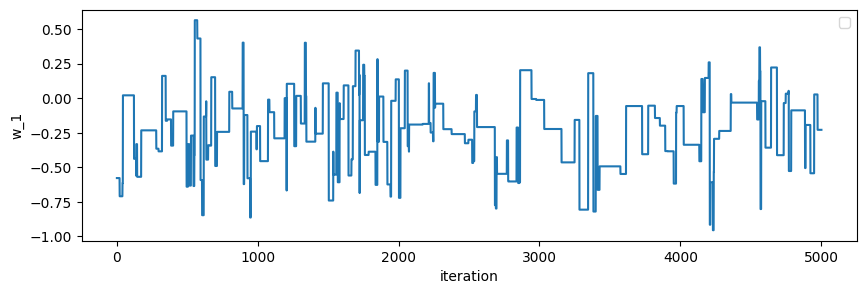

In [488]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        ##############################################
        # Your solution goes here
        ##############################################
        

        # get the last value for theta and generate new proposal candidate
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
        
        # evaluate the log density for the candidate sample
        log_p_theta_star = log_target(theta_star)

        # compute acceptance probability
        log_r = log_p_theta_star - log_p_theta
        A = min(1, jnp.exp(log_r))
        
        # accept new candidate with probability A
        if random.uniform(key_accept) < A:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)


        
        ##############################################
        # End of solution
        ##############################################
            
        thetas.append(theta_next)


        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas


from scipy.stats import poisson
# specify number of parameters in the target distribution
num_params = 2
alpha = 8

x_data = jnp.array([1, 2, 3])
y_data = jnp.array([10, 4, 1])

# specify the target distribution
def log_joint(theta):
    w1 = theta[0]
    w2 = theta[1]
    return mvn.logpdf(x=theta, mean=jnp.array([0,0]),  cov=((1/alpha) * jnp.eye(len(theta)))) + jnp.sum(poisson.logpmf(y_data, jnp.exp(3 + w1*x_data + w2 * x_data**2)))

# specify the parameters of the MH algorithm
num_iterations = 10**4
warm_up = int(0.5*num_iterations)
tau = 1

# run sampler
thetas = metropolis(log_joint, num_params, tau, num_iterations, theta_init=jnp.array([0,0]), seed=0)

thetas_after_warmup = thetas[warm_up:, :]
x_line = jnp.linspace(1, len(thetas_after_warmup), len(thetas_after_warmup))
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(x_line, thetas_after_warmup[:, 0])
ax.set(xlabel='iteration', ylabel='w_1')
ax.legend();

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


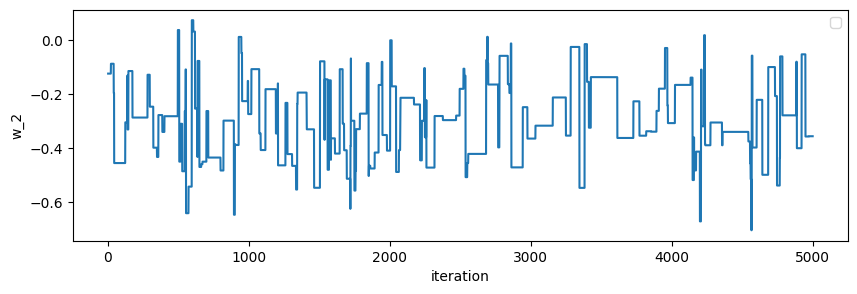

In [489]:
thetas_after_warmup = thetas[warm_up:, :]
x_line = jnp.linspace(1, len(thetas_after_warmup), len(thetas_after_warmup))
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(x_line, thetas_after_warmup[:, 1])
ax.set(xlabel='iteration', ylabel='w_2')
ax.legend();

### 4.4

In [490]:
w1s = thetas_after_warmup[:, 0]
w2s = thetas_after_warmup[:, 1]

jnp.mean(w1s > 0)

Array(0.16436712, dtype=float32)

### 4.5

In [491]:
xstar = 1.5
jnp.mean(jnp.exp(3 + w1s * xstar + w2s * xstar**2) > 7)

Array(0.6538692, dtype=float32)

### 4.6

In [492]:
xstar = 1.5
key = random.PRNGKey(0)

mu_samples = jnp.exp(3 + w1s*xstar + w2s*xstar**2)

y_samples = random.poisson(key, mu_samples)

y_lower = jnp.quantile(y_samples.astype(float), 0.05)
y_upper = jnp.quantile(y_samples.astype(float), 1-0.05)

print(f"y interval:  [{y_lower:.2f}, {y_upper:.2f}]")

y interval:  [3.00, 13.00]


## Part 5

### 5.1

In [493]:
key = random.PRNGKey(1)
key1, key2, key3, key4 = random.split(key, num=4)

S = 1000
w = 0       + random.normal(key1, shape=(S, ))
y = jnp.exp(w) + random.normal(key2, shape=(S, ))

jnp.mean(y)

Array(1.6243263, dtype=float32)

### 5.2

In [494]:
log_npdf(5, jnp.exp(1.293404), 1) + log_npdf(1.293404, 0, 1)

Array(-3.5921013, dtype=float32, weak_type=True)

### 5.3

In [495]:
w_MAP = 1.293404

def log_joint_density(ww):
    yy = 5
    return log_npdf(yy, jnp.exp(ww), 1) + log_npdf(ww, 0, 1)

cost_fun = lambda ww: -log_joint_density(ww)

A = hessian(cost_fun)(w_MAP)

In [496]:
w_MAP, A**(-1)

(1.293404, Array(0.1069666, dtype=float32, weak_type=True))

### 5.4

Gaussian is symmetric around its mean, so 50%.

Can estimate with MC:

In [497]:
S = 10000

gaus_samples = 1.293404       + jnp.sqrt(0.1069666)*random.normal(key1, shape=(S, ))

jnp.mean(gaus_samples > w_MAP)

Array(0.4994, dtype=float32)